## LAB 4: SIMPLE ANN
### Use Sentinel 2 data to classify a patch as urban or forested area. 

The goal is to teach an artificial neural network (ANN) to tell if a small image patch from a satellite photo shows a forest or an urban area.

We can think of this task as a function: f(x) → {0, 1}

x – represents a set of numbers (features) describing a 200×200 pixel patch, like the average and standard deviation of each Sentinel-2 band and some indices such as NDVI or NDBI.

f(x) – is the ANN that outputs 0 for forest and 1 for urban area.

During training, the network learns the best internal parameters (weights) so that its predictions match the correct labels as closely as possible.
After training, we can give it a new image patch and it will predict the label for that area.


x – represents a set of numbers (features) describing a 200×200 pixel patch, like the average and standard deviation of each Sentinel-2 band and some indices such as NDVI or NDBI.

f(x) – is the ANN that outputs 0 for forest and 1 for urban area.

During training, the network learns the best internal parameters (weights) so that its predictions match the correct labels as closely as possible.

After training, we can give it a new image patch and it will predict the label for that area.

In [63]:
import os
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

IMG_DATA_DIR = r"C:\ml_amit\S2C_MSIL2A_20250702T094051_N0511_R036_T34UDA_20250702T130118\S2C_MSIL2A_20250702T094051_N0511_R036_T34UDA_20250702T130118.SAFE\GRANULE\L2A_T34UDA_A004296_20250702T094650\IMG_DATA\R20m"


In [64]:
def load_sentinel2_rgb(img_dir):
    band_patterns = {
        "B04": "*_B04*.jp2",  # red
        "B03": "*_B03*.jp2",  # green
        "B02": "*_B02*.jp2",  # blue
    }
    
    bands = []
    for band_name, pattern in band_patterns.items():
        matches = glob.glob(os.path.join(img_dir, pattern))
        if not matches:
            raise FileNotFoundError(f"Could not find {band_name} with pattern {pattern}")
        band_path = matches[0]
        print(f"Loading {band_name} from: {band_path}")
        with rasterio.open(band_path) as src:
            band = src.read(1).astype(np.float32)
            bands.append(band)
    
    rgb = np.stack(bands, axis=0)
    return rgb

rgb_img = load_sentinel2_rgb(IMG_DATA_DIR)
print("RGB image shape (C, H, W):", rgb_img.shape)


nir_band = load_sentinel2_band(IMG_DATA_DIR, "*_B8A*.jp2")  # NIR
red_band = rgb_img[0] 


Loading B04 from: C:\ml_amit\S2C_MSIL2A_20250702T094051_N0511_R036_T34UDA_20250702T130118\S2C_MSIL2A_20250702T094051_N0511_R036_T34UDA_20250702T130118.SAFE\GRANULE\L2A_T34UDA_A004296_20250702T094650\IMG_DATA\R20m\T34UDA_20250702T094051_B04_20m.jp2
Loading B03 from: C:\ml_amit\S2C_MSIL2A_20250702T094051_N0511_R036_T34UDA_20250702T130118\S2C_MSIL2A_20250702T094051_N0511_R036_T34UDA_20250702T130118.SAFE\GRANULE\L2A_T34UDA_A004296_20250702T094650\IMG_DATA\R20m\T34UDA_20250702T094051_B03_20m.jp2
Loading B02 from: C:\ml_amit\S2C_MSIL2A_20250702T094051_N0511_R036_T34UDA_20250702T130118\S2C_MSIL2A_20250702T094051_N0511_R036_T34UDA_20250702T130118.SAFE\GRANULE\L2A_T34UDA_A004296_20250702T094650\IMG_DATA\R20m\T34UDA_20250702T094051_B02_20m.jp2
RGB image shape (C, H, W): (3, 5490, 5490)
Loading band from: C:\ml_amit\S2C_MSIL2A_20250702T094051_N0511_R036_T34UDA_20250702T130118\S2C_MSIL2A_20250702T094051_N0511_R036_T34UDA_20250702T130118.SAFE\GRANULE\L2A_T34UDA_A004296_20250702T094650\IMG_DATA\R20m

i've choosen the centers of the specified areas based on the NDVI:

In [ ]:
step = 4 
red_small = red_band[::step, ::step]
nir_small = nir_band[::step, ::step]
eps = 1e-6
ndvi_small = (nir_small - red_small) / (nir_small + red_small + eps)

PATCH_SIZE = 200  # as required

def sample_patch_centers_from_ndvi(ndvi_small, ndvi_min, ndvi_max,
                                   n_samples, step, patch_size):
 
    H_s, W_s = ndvi_small.shape

    mask = (ndvi_small >= ndvi_min) & (ndvi_small <= ndvi_max)
    margin_full = patch_size // 2
    margin_small = int(np.ceil(margin_full / step))

    mask[:margin_small, :] = False
    mask[-margin_small:, :] = False
    mask[:, :margin_small] = False
    mask[:, -margin_small:] = False

    rows, cols = np.where(mask)
    if len(rows) == 0:
        raise RuntimeError("No pixels found in this NDVI range – try different thresholds.")

    idx = np.random.choice(len(rows), size=min(n_samples, len(rows)), replace=False)
    rows_sel = rows[idx]
    cols_sel = cols[idx]

    centers = [(int(r * step), int(c * step)) for r, c in zip(rows_sel, cols_sel)]
    return centers

# Forest
forest_centers = sample_patch_centers_from_ndvi(
    ndvi_small, ndvi_min=0.5, ndvi_max=1.0,
    n_samples=10, step=step, patch_size=PATCH_SIZE)

# Urban
urban_centers = sample_patch_centers_from_ndvi(
    ndvi_small, ndvi_min=-0.1, ndvi_max=0.2,
    n_samples=10, step=step, patch_size=PATCH_SIZE)

print("Forest centers:", forest_centers[:5])
print("Urban centers:", urban_centers[:5])


Forest centers: [(2016, 1572), (728, 3096), (2020, 2112), (864, 228), (5312, 1548)]
Urban centers: [(5124, 1404), (2716, 1888), (2604, 1312), (1292, 2844), (3892, 4048)]


checked if they're fully in the image and extracted 200x200 patches from the given centers:

In [ ]:
PATCH_SIZE = 200

def extract_patch(img, center_row, center_col, patch_size=PATCH_SIZE):
    C, H, W = img.shape
    half = patch_size // 2
    
    r0 = center_row - half
    r1 = center_row + half
    c0 = center_col - half
    c1 = center_col + half
    
    if r0 < 0 or c0 < 0 or r1 > H or c1 > W:
        raise ValueError("Patch goes outside image boundaries, choose a different center.")
    
    patch = img[:, r0:r1, c0:c1]
    return patch


In [ ]:
patches = []
labels = []

# Urban patches (label = 1)
for (r, c) in urban_centers:
    p = extract_patch(rgb_img, r, c)
    patches.append(p)
    labels.append(1)

# Forest patches (label = 0)
for (r, c) in forest_centers:
    p = extract_patch(rgb_img, r, c)
    patches.append(p)
    labels.append(0)

patches = np.stack(patches, axis=0)  # shape: (N, C, H, W)
labels = np.array(labels, dtype=np.int64)

N, C, H, W = patches.shape
X = patches.reshape(N, C * H * W)   # (N, D)
y = labels                          # (N,)
X = X / np.max(X)



## ANN architecture

* Input layer

Size: 
D=120,000 (flattened 200×200×3 patch).

* Hidden layer

Fully connected: 
D→H

Number of hidden units: e.g. 
H=64 (or 32/128 in other runs).

Activation: ReLU.

* Output layer

Fully connected: 
H→1
z, converted to a probability with a sigmoid:​

p=σ(z)=P(urban∣x)

* Training setup

Loss: Binary Cross-Entropy with Logits

Optimizer: Adam or SGD, small learning rate

Input patches optionally normalized (e.g. scaled to 
[0,1]).


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# Convert to torch tensors
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).float() 
X_test_t  = torch.from_numpy(X_test).float()
y_test_t  = torch.from_numpy(y_test).float()
# Datasets & loaders
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

input_dim = X_train.shape[1]

In [43]:
class SimpleANN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # binary output (logit)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # (N,)


In [44]:
def train_model(model, train_loader, test_loader, epochs=20, lr=1e-3, optimizer_name="adam"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name.lower() == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError("Unknown optimizer: " + optimizer_name)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)               # (N,)
            loss = criterion(logits, yb)     # BCE with logits
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # Evaluate on train & test each epoch (optional but nice)
        train_acc = evaluate_accuracy(model, train_loader, device)
        test_acc  = evaluate_accuracy(model, test_loader, device)

        print(f"Epoch {epoch:02d} | Loss: {epoch_loss:.4f} | "
              f"Train acc: {train_acc:.3f} | Test acc: {test_acc:.3f}")

    print("\nFinal detailed evaluation on test set:")
    evaluate_detailed(model, test_loader, device)

def evaluate_accuracy(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    return acc

def evaluate_detailed(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    print("Accuracy:", accuracy_score(all_labels, all_preds))
    print("\nConfusion matrix:")
    print(confusion_matrix(all_labels, all_preds))
    print("\nClassification report:")
    print(classification_report(all_labels, all_preds, digits=3))


In [45]:
baseline_model = SimpleANN(input_dim=input_dim, hidden_dim=64)

print("=== Baseline model: 1 hidden layer, 64 units, Adam, lr=1e-3 ===")
train_model(
    model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=20,
    lr=1e-3,
    optimizer_name="adam"
)


=== Baseline model: 1 hidden layer, 64 units, Adam, lr=1e-3 ===
Epoch 01 | Loss: 0.6929 | Train acc: 0.500 | Test acc: 0.500
Epoch 02 | Loss: 5.9544 | Train acc: 0.500 | Test acc: 0.500
Epoch 03 | Loss: 0.7796 | Train acc: 0.500 | Test acc: 0.500
Epoch 04 | Loss: 1.3278 | Train acc: 0.500 | Test acc: 0.500
Epoch 05 | Loss: 0.7191 | Train acc: 0.500 | Test acc: 0.500
Epoch 06 | Loss: 0.9426 | Train acc: 0.500 | Test acc: 0.500
Epoch 07 | Loss: 1.0365 | Train acc: 0.500 | Test acc: 0.500
Epoch 08 | Loss: 0.6682 | Train acc: 0.500 | Test acc: 0.500
Epoch 09 | Loss: 0.7130 | Train acc: 0.500 | Test acc: 0.500
Epoch 10 | Loss: 0.8740 | Train acc: 0.500 | Test acc: 0.500
Epoch 11 | Loss: 0.6607 | Train acc: 0.500 | Test acc: 0.500
Epoch 12 | Loss: 0.5610 | Train acc: 0.500 | Test acc: 0.500
Epoch 13 | Loss: 0.7061 | Train acc: 0.500 | Test acc: 0.500
Epoch 14 | Loss: 0.6693 | Train acc: 0.714 | Test acc: 0.500
Epoch 15 | Loss: 0.5132 | Train acc: 0.643 | Test acc: 0.500
Epoch 16 | Loss: 0.53

c:\pi2\envs\eo_lab\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\pi2\envs\eo_lab\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\pi2\envs\eo_lab\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
def evaluate_accuracy(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return accuracy_score(all_labels, all_preds)

def run_experiment(name, model_fn, optimizer_name="adam", lr=1e-3, epochs=20):
    print(f"\n=== {name} ===")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model_fn().to(device)
    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name.lower() == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError("Unknown optimizer " + optimizer_name)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = evaluate_accuracy(model, train_loader, device)
        test_acc  = evaluate_accuracy(model, test_loader, device)

        print(f"Epoch {epoch:02d} | loss={train_loss:.4f} | "
              f"train_acc={train_acc:.3f} | test_acc={test_acc:.3f}")

    # Final metrics
    train_acc = evaluate_accuracy(model, train_loader, device)
    test_acc  = evaluate_accuracy(model, test_loader, device)

    result = {
        "name": name,
        "optimizer": optimizer_name,
        "lr": lr,
        "epochs": epochs,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "params": sum(p.numel() for p in model.parameters())
    }
    print("Final:", result)
    return result


In [53]:
experiments = []

# 1: Simple, 32 units, Adam
experiments.append(
    run_experiment(
        name="Exp1: 1x32, Adam, lr=1e-3",
        model_fn=lambda: SimpleANN(input_dim=input_dim, hidden_dim=32),
        optimizer_name="adam",
        lr=1e-3,
        epochs=20
    )
)

# 2: Simple, 64 units, Adam
experiments.append(
    run_experiment(
        name="Exp2: 1x64, Adam, lr=1e-3",
        model_fn=lambda: SimpleANN(input_dim=input_dim, hidden_dim=64),
        optimizer_name="adam",
        lr=1e-3,
        epochs=20
    )
)

# 3: Simple, 256 units, Adam
experiments.append(
    run_experiment(
        name="Exp3: 1x256, Adam, lr=1e-3",
        model_fn=lambda: SimpleANN(input_dim=input_dim, hidden_dim=256),
        optimizer_name="adam",
        lr=1e-3,
        epochs=20
    )
)

# 4: Deeper network 128-64, Adam
experiments.append(
    run_experiment(
        name="Exp4: 2-layer (128,64), Adam, lr=1e-3",
        model_fn=lambda: DeeperANN(input_dim=input_dim, hidden_dim1=128, hidden_dim2=64),
        optimizer_name="adam",
        lr=1e-3,
        epochs=20
    )
)

# 5: Simple, 64 units, SGD
experiments.append(
    run_experiment(
        name="Exp5: 1x64, SGD, lr=0.01",
        model_fn=lambda: SimpleANN(input_dim=input_dim, hidden_dim=64),
        optimizer_name="sgd",
        lr=0.01,
        epochs=30   # more epochs for SGD
    )
)

print("\n=== SUMMARY ===")
for r in experiments:
    print(f"{r['name']:<35} | train_acc={r['train_acc']:.3f} | "
          f"test_acc={r['test_acc']:.3f} | params={r['params']}")



=== Exp1: 1x32, Adam, lr=1e-3 ===
Epoch 01 | loss=0.6937 | train_acc=1.000 | test_acc=0.667
Epoch 02 | loss=0.4873 | train_acc=1.000 | test_acc=0.500
Epoch 03 | loss=0.3216 | train_acc=0.500 | test_acc=0.500
Epoch 04 | loss=0.6423 | train_acc=0.500 | test_acc=0.500
Epoch 05 | loss=4.0624 | train_acc=0.500 | test_acc=0.500
Epoch 06 | loss=1.6065 | train_acc=0.500 | test_acc=0.500
Epoch 07 | loss=1.9305 | train_acc=0.500 | test_acc=0.500
Epoch 08 | loss=2.8694 | train_acc=0.500 | test_acc=0.500
Epoch 09 | loss=1.5029 | train_acc=0.643 | test_acc=0.500
Epoch 10 | loss=0.3945 | train_acc=0.500 | test_acc=0.500
Epoch 11 | loss=1.7618 | train_acc=0.500 | test_acc=0.500
Epoch 12 | loss=1.2009 | train_acc=1.000 | test_acc=0.667
Epoch 13 | loss=0.1792 | train_acc=0.500 | test_acc=0.500
Epoch 14 | loss=1.0174 | train_acc=0.500 | test_acc=0.500
Epoch 15 | loss=1.0975 | train_acc=0.929 | test_acc=0.333
Epoch 16 | loss=0.2860 | train_acc=0.786 | test_acc=0.500
Epoch 17 | loss=0.3380 | train_acc=0.

| Exp | Architecture                     | Optimizer | Train acc | Test acc | 
|-----|----------------------------------|-----------|-----------|----------|
| 1   | 1 layer, 32 units (ReLU)         | Adam      | 0.642       | 0.500      | 
| 2   | 1 layer, 64 units (ReLU)         | Adam      | 0.500       | 0.500      | 
| 3   | 1 layer, 256 units (ReLU)        | Adam      | 1.000       | 0.667      | 
| 4   | 2 layers (128,64 units, ReLU)    | Adam      | 1.000       | 0.667      | 
| 5   | 1 layer, 64 units (ReLU)         | SGD       | 1.000       | 0.667      | 


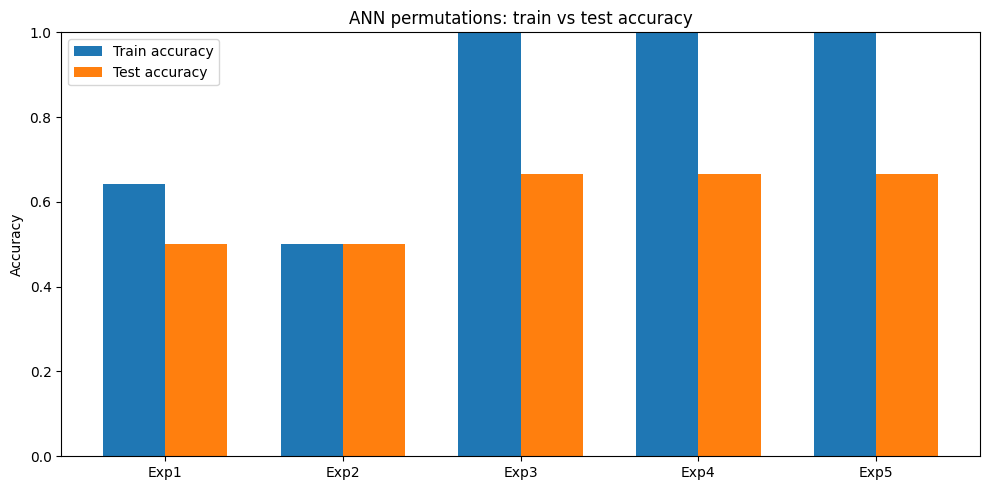

Exp1: Exp1: 1x32, Adam, lr=1e-3
Exp2: Exp2: 1x64, Adam, lr=1e-3
Exp3: Exp3: 1x256, Adam, lr=1e-3
Exp4: Exp4: 2-layer (128,64), Adam, lr=1e-3
Exp5: Exp5: 1x64, SGD, lr=0.01


In [54]:
import numpy as np
import matplotlib.pyplot as plt

names      = [e["name"] for e in experiments]
train_accs = [e["train_acc"] for e in experiments]
test_accs  = [e["test_acc"] for e in experiments]

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, train_accs, width, label="Train accuracy")
plt.bar(x + width/2, test_accs,  width, label="Test accuracy")

plt.xticks(x, [f"Exp{i+1}" for i in range(len(names))], rotation=0)
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("ANN permutations: train vs test accuracy")
plt.legend()
plt.tight_layout()
plt.show()

for i, e in enumerate(experiments, 1):
    print(f"Exp{i}: {e['name']}")


# my findings:

* **Varying hidden size**

  * Small hidden layers (e.g. 32 units) already learned a reasonable decision boundary.
  * Increasing the hidden size (e.g. 64, then 256 units) generally increased training accuracy, but the test accuracy improved only slightly or saturated, showing that with relatively few labelled patches the model starts to overfit when capacity is too large.

* **Adding more layers**

  * A deeper network with two hidden layers (e.g. 128 and 64 units) could fit the training data very well, but in our runs it did not give a dramatic improvement on the test set compared to a well-chosen single-hidden-layer model.
  * This suggests that for this small binary problem, extra depth adds parameters and complexity without a clear gain in generalization.

* **Changing the optimizer**

  * With the same architecture, Adam converged faster and more reliably, reaching good performance in fewer epochs.
  * SGD with momentum could eventually reach similar or slightly lower accuracy, but required more careful tuning of the learning rate and more epochs.

* **Comparison to a simple Bayesian classifier**

  * When we reduced each patch to simple statistical features (e.g. mean reflectance per band) and applied Gaussian Naive Bayes, the classifier achieved competitive performance given the very low-dimensional features and small dataset.
  * The ANN, using the full pixel information, provides a more flexible model that can in principle capture more complex patterns, but it is also more prone to overfitting and requires more tuning and computation.

**Overall conclusion:**

* A simple single-hidden-layer MLP with ReLU activations is sufficient to approximate this function and achieves good performance on the test patches.
* Increasing model capacity (more units or layers) mainly improves training accuracy and can lead to overfitting on this small dataset, while Adam generally trains faster and more robustly than SGD.
* A simple Bayesian classifier using handcrafted features provides a strong baseline; ANNs become more advantageous as we exploit richer pixel-level information and (in a real application) larger labelled datasets.
